In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
np.random.seed(42)
n = 200

study_hours = np.round(np.random.normal(5, 2, n).clip(0, 12), 1)
attendance  = np.round(np.random.normal(75, 15, n).clip(30, 100), 1)
prev_score  = np.round(np.random.normal(65, 15, n).clip(20, 100), 1)
assignments = np.random.randint(0, 11, n)

score = (study_hours * 3 + attendance * 0.3 + prev_score * 0.4 + assignments * 1.5)
threshold = np.percentile(score, 35)
passed = (score >= threshold).astype(int)

df = pd.DataFrame({
    'study_hours' : study_hours,
    'attendance'  : attendance,
    'prev_score'  : prev_score,
    'assignments' : assignments,
    'passed'      : passed
})

print(df.head(10))

   study_hours  attendance  prev_score  assignments  passed
0          6.0        80.4        41.1            3       0
1          4.7        83.4        56.0            1       0
2          6.3        91.2        65.1           10       1
3          8.0        90.8        65.7            2       1
4          4.5        54.3        58.2            2       0
5          4.5        60.9        74.3            3       0
6          8.2        82.7        49.0            3       1
7          6.5        82.7        62.9            9       1
8          4.1        82.7        66.8           10       1
9          6.1       100.0        72.7           10       1


In [12]:
df.to_csv("dataset.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [13]:
print("Total Students:", len(df))
print("Students Passed:", df['passed'].sum())
print("Students Failed:", (df['passed'] == 0).sum())
print()
print("Average Study Hours:", df['study_hours'].mean().round(2))
print("Average Attendance:", df['attendance'].mean().round(2))
print("Average Previous Score:", df['prev_score'].mean().round(2))
print()
print(df.describe().round(2))

Total Students: 200
Students Passed: 130
Students Failed: 70

Average Study Hours: 4.92
Average Attendance: 75.85
Average Previous Score: 63.66

       study_hours  attendance  prev_score  assignments  passed
count       200.00      200.00      200.00       200.00  200.00
mean          4.92       75.85       63.66         4.82    0.65
std           1.85       13.71       14.75         3.17    0.48
min           0.00       30.00       27.90         0.00    0.00
25%           3.60       65.92       53.08         2.00    0.00
50%           5.00       76.15       63.85         5.00    1.00
75%           6.00       85.32       73.60         7.00    1.00
max          10.40      100.00      100.00        10.00    1.00


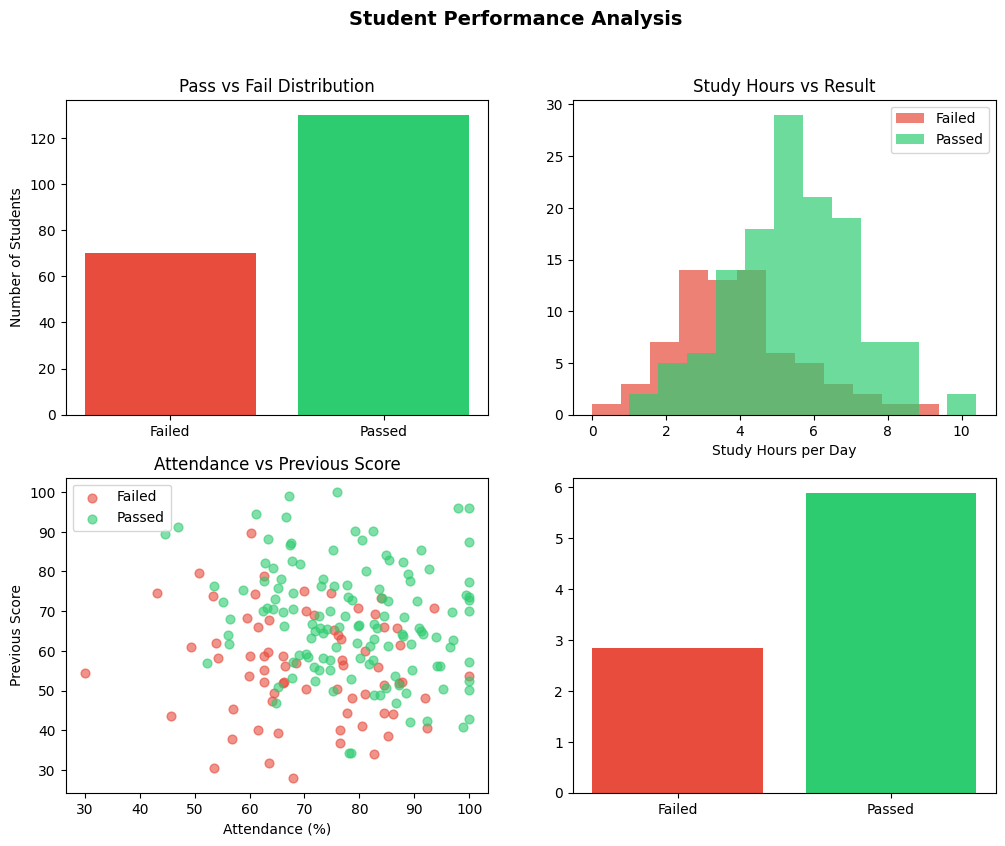

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Student Performance Analysis',
             fontsize=14, fontweight='bold')

# Chart 1: Pass vs Fail count
ax1 = axes[0, 0]
labels = ['Failed', 'Passed']
counts = [df['passed'].value_counts()[0], df['passed'].value_counts()[1]]
ax1.bar(labels, counts, color=['#E74C3C', '#2ECC71'])
ax1.set_title('Pass vs Fail Distribution')
ax1.set_ylabel('Number of Students')

# Chart 2: Study Hours distribution
ax2 = axes[0, 1]
failed = df[df['passed'] == 0]
passed_df = df[df['passed'] == 1]
ax2.hist(failed['study_hours'], alpha=0.7, color='#E74C3C', label='Failed', bins=12)
ax2.hist(passed_df['study_hours'], alpha=0.7, color='#2ECC71', label='Passed', bins=12)
ax2.set_title('Study Hours vs Result')
ax2.set_xlabel('Study Hours per Day')
ax2.legend()

# Chart 3: Attendance vs Previous Score
ax3 = axes[1, 0]
ax3.scatter(failed['attendance'], failed['prev_score'],
            alpha=0.6, color='#E74C3C', label='Failed', s=40)
ax3.scatter(passed_df['attendance'], passed_df['prev_score'],
            alpha=0.6, color='#2ECC71', label='Passed', s=40)
ax3.set_title('Attendance vs Previous Score')
ax3.set_xlabel('Attendance (%)')
ax3.set_ylabel('Previous Score')
ax3.legend()

# Chart 4: Assignments completed
ax4 = axes[1, 1]
avg_assign = df.groupby('passed')['assignments'].mean()
ax4.bar(['Failed', 'Passed'], avg_assign.values,
        color=['#E74C3C', '#2ECC71'])
plt.savefig("student_analysis.png")

In [15]:
# Separate features and target
X = df[['study_hours', 'attendance', 'prev_score', 'assignments']]
y = df['passed']

print("Input features shape:", X.shape)
print("Target shape:", y.shape)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print()
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print()
print("Model trained successfully!")

Input features shape: (200, 4)
Target shape: (200,)

Training samples: 160
Testing samples : 40

Model trained successfully!


In [16]:
# Model predicts on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")
print()

# Detailed report
print("Detailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Failed', 'Passed']))

Model Accuracy: 95.0 %

Detailed Report:
              precision    recall  f1-score   support

      Failed       0.92      0.92      0.92        12
      Passed       0.96      0.96      0.96        28

    accuracy                           0.95        40
   macro avg       0.94      0.94      0.94        40
weighted avg       0.95      0.95      0.95        40



In [17]:
# New student details
print("New Student Details:")
print("Study Hours  : 6 hrs/day")
print("Attendance   : 80%")
print("Previous Score: 70")
print("Assignments  : 7 out of 10")
print()

# Create new student data
new_student = np.array([[6, 80, 70, 7]])

# Model predicts
prediction = model.predict(new_student)[0]
probability = model.predict_proba(new_student)[0]

print("Prediction:", "PASS ✅" if prediction == 1 else "FAIL ❌")
print("Confidence:", round(max(probability) * 100, 2), "%")
print()

# Try a weak student
print("Weak Student Details:")
print("Study Hours  : 1 hr/day")
print("Attendance   : 40%")
print("Previous Score: 30")
print("Assignments  : 2 out of 10")
print()

weak_student = np.array([[1, 40, 30, 2]])
prediction2 = model.predict(weak_student)[0]
probability2 = model.predict_proba(weak_student)[0]

print("Prediction:", "PASS ✅" if prediction2 == 1 else "FAIL ❌")
print("Confidence:", round(max(probability2) * 100, 2), "%")

New Student Details:
Study Hours  : 6 hrs/day
Attendance   : 80%
Previous Score: 70
Assignments  : 7 out of 10

Prediction: PASS ✅
Confidence: 100.0 %

Weak Student Details:
Study Hours  : 1 hr/day
Attendance   : 40%
Previous Score: 30
Assignments  : 2 out of 10

Prediction: FAIL ❌
Confidence: 100.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [18]:
# Predict for Vasi Ragini
print("Student: Vasi Ragini")
print("Study Hours   : 6 hrs/day")
print("Attendance    : 88%")
print("Previous Score: 91")
print("Assignments   : 9 out of 10")
print()

vasi = np.array([[6, 88, 91, 9]])

prediction = model.predict(vasi)[0]
probability = model.predict_proba(vasi)[0]

print("Prediction :", "PASS ✅" if prediction == 1 else "FAIL ❌")
print("Confidence :", round(max(probability) * 100, 2), "%")

Student: Vasi Ragini
Study Hours   : 6 hrs/day
Attendance    : 88%
Previous Score: 91
Assignments   : 9 out of 10

Prediction : PASS ✅
Confidence : 100.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
